<a href="https://colab.research.google.com/github/ArjunS07/cs159-sp26/blob/main/failure_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early-Failure Classifier
Predicts episode failure from early uncertainty + action signals.

**Models:** scalar-u (raw) | Logistic Regression | Random Forest | GBM | MLP
**Evaluation:** stratified 5-fold CV, OOF predictions, F1-optimal threshold
**Features:** per-chunk (u_vec, a_mean_vec) concatenated up to cutoff k

## 0. Environment setup
_Run once per Colab session before anything else._

In [ ]:
import subprocess, torch
from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE       = '/content/drive/MyDrive'
CACHE_DIR   = f'{DRIVE}/cs159_jeff/smolvla_colab_cache'
RESULTS_DIR = f'{DRIVE}/cs159_jeff/libero_pro_results'
DB_PATH     = f'{RESULTS_DIR}/rollouts_jeff_dimensional.db'
HF_HOME     = f'{CACHE_DIR}/hf_models'

os.makedirs(CACHE_DIR,   exist_ok=True)
os.makedirs(HF_HOME,     exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

os.environ['HF_HOME']                = HF_HOME
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['MUJOCO_GL']              = 'egl'

print(subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
    capture_output=True, text=True).stdout.strip())
print(f'CUDA: {torch.cuda.is_available()}')

Mounted at /content/drive
NVIDIA A100-SXM4-80GB, 81920 MiB
CUDA: True


In [ ]:
# ── Full pip install — run ONCE to create the snapshot, then use cell below ──
# Only needed if SNAPSHOT does not exist on Drive yet.
import subprocess, os
SNAPSHOT = f'{CACHE_DIR}/site_packages.tar.gz'

if os.path.exists(SNAPSHOT):
    print(f'Snapshot already exists ({os.path.getsize(SNAPSHOT)//1024//1024} MB) — skip this cell.')
else:
    packages = [
        'git+https://github.com/huggingface/lerobot.git#egg=lerobot[smolvla]',
        'mujoco', 'robosuite', 'libero',
    ]
    for pkg in packages:
        print(f'Installing {pkg}...')
        subprocess.run(['pip', 'install', '-q', pkg], check=True)
    import sys
    subprocess.run(
        ['tar', '-czf', SNAPSHOT, '-C', '/usr/local/lib',
         f'python3.{sys.version_info.minor}/dist-packages'],
        check=True)
    print(f'Snapshot saved: {SNAPSHOT}')

Snapshot already exists (10679 MB) — skip this cell.


In [ ]:
# ── Restore packages from snapshot (every session after the first) ───────────
import subprocess, sys, os, time, shutil, importlib

LOCAL_SNAPSHOT = '/content/site_packages_restore.tar.gz'
SNAPSHOT       = f'{CACHE_DIR}/site_packages.tar.gz'

if not os.path.exists(SNAPSHOT):
    raise FileNotFoundError('No snapshot — run the install cell above first.')

t0 = time.time()
print(f'Snapshot: {os.path.getsize(SNAPSHOT)//1024//1024} MB — copying to local disk...')
shutil.copy(SNAPSHOT, LOCAL_SNAPSHOT)
print('Extracting...')
result = subprocess.run(['tar', '-xzf', LOCAL_SNAPSHOT, '-C', '/'],
                        capture_output=True, text=True)
os.remove(LOCAL_SNAPSHOT)
if result.returncode != 0:
    print('Restore failed:', result.stderr[:500])
else:
    print(f'Restored in {time.time()-t0:.1f}s')

importlib.invalidate_caches()
for pkg in ['mujoco', 'robosuite', 'libero', 'lerobot']:
    try:    importlib.import_module(pkg); print(f'  {pkg} OK')
    except ImportError as e: print(f'  {pkg} MISSING: {e}')

Snapshot: 10679 MB — copying to local disk...
Extracting...


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.12/dist-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


Restored in 338.3s
  mujoco OK
  robosuite OK
  libero OK
  lerobot OK


In [ ]:
# ── Restore packages from snapshot (every session after the first) ───────────
import subprocess, sys, os, time, shutil, importlib

LOCAL_SNAPSHOT = '/content/site_packages_restore.tar.gz'
SNAPSHOT       = f'{CACHE_DIR}/site_packages.tar.gz'

if not os.path.exists(SNAPSHOT):
    raise FileNotFoundError('No snapshot — run the install cell above first.')

t0 = time.time()
print(f'Snapshot: {os.path.getsize(SNAPSHOT)//1024//1024} MB — copying to local disk...')
shutil.copy(SNAPSHOT, LOCAL_SNAPSHOT)
print('Extracting...')
result = subprocess.run(['tar', '-xzf', LOCAL_SNAPSHOT, '-C', '/'],
                        capture_output=True, text=True)
os.remove(LOCAL_SNAPSHOT)
if result.returncode != 0:
    print('Restore failed:', result.stderr[:500])
else:
    print(f'Restored in {time.time()-t0:.1f}s')

importlib.invalidate_caches()
for pkg in ['mujoco', 'robosuite', 'libero', 'lerobot']:
    try:    importlib.import_module(pkg); print(f'  {pkg} OK')
    except ImportError as e: print(f'  {pkg} MISSING: {e}')

Snapshot: 10679 MB — copying to local disk...
Extracting...
Restored in 235.2s
  mujoco OK
  robosuite OK
  libero OK
  lerobot OK


In [ ]:
import subprocess, os

REPO_DIR = '/content/LIBERO-PRO'
if not os.path.exists(REPO_DIR):
    print('Cloning LIBERO-PRO...')
    result = subprocess.run(
        ['git', 'clone', '--depth=1',
         'https://github.com/Zxy-MLlab/LIBERO-PRO.git',
         REPO_DIR],
        capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(f'Clone failed: {result.stderr}')
    print('Clone complete.')
else:
    print(f'Repo already exists at {REPO_DIR}')

Cloning LIBERO-PRO...
Clone complete.


In [ ]:
# ── Patch LIBERO-PRO files into the installed libero package ──────────────────
import shutil, os, sys

LIBERO_SITE    = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
LIBERO_PRO_DIR = '/content/LIBERO-PRO'

files_to_patch = [
    'benchmark/__init__.py',
    'benchmark/libero_suite_task_map.py',
    'envs/objects/__init__.py',
]
for rel_path in files_to_patch:
    src = os.path.join(LIBERO_PRO_DIR, 'libero/libero', rel_path)
    dst = os.path.join(LIBERO_SITE, rel_path)
    if not os.path.exists(src):
        print(f'SKIP (not found in clone): {rel_path}'); continue
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    bak = dst + '.original_bak'
    if os.path.exists(dst) and not os.path.exists(bak):
        shutil.copy2(dst, bak)
    shutil.copy2(src, dst)
    print(f'Patched: {rel_path}')

src_objects = os.path.join(LIBERO_PRO_DIR, 'libero/libero/envs/objects')
dst_objects = os.path.join(LIBERO_SITE, 'envs/objects')
for fname in os.listdir(src_objects):
    if not fname.endswith('.py'): continue
    dst_file = os.path.join(dst_objects, fname)
    if not os.path.exists(dst_file):
        shutil.copy2(os.path.join(src_objects, fname), dst_file)
        print(f'Added object: {fname}')

# ── Copy BDDL files for LIBERO-PRO custom suites ──────────────────────────────
PRO_BDDL = os.path.join(LIBERO_PRO_DIR, 'libero/libero/bddl_files')
SYS_BDDL = os.path.join(LIBERO_SITE, 'bddl_files')
if os.path.exists(PRO_BDDL):
    for suite_dir in os.listdir(PRO_BDDL):
        src_suite = os.path.join(PRO_BDDL, suite_dir)
        dst_suite = os.path.join(SYS_BDDL, suite_dir)
        if not os.path.isdir(src_suite): continue
        if os.path.exists(dst_suite):
            print(f'BDDL exists: {suite_dir}'); continue
        shutil.copytree(src_suite, dst_suite)
        n = len([f for f in os.listdir(dst_suite) if f.endswith('.bddl')])
        print(f'Copied {n} BDDL files: {suite_dir}')
else:
    print('WARN: LIBERO-PRO bddl_files not found — run clone cell first')

# ── Apply .get() patch to benchmark __init__ ──────────────────────────────────
benchmark_init = os.path.join(LIBERO_SITE, 'benchmark/__init__.py')
with open(benchmark_init) as f: content = f.read()
old = 'for task in libero_task_map[libero_suite]:'
new = 'for task in libero_task_map.get(libero_suite, []):'
if old in content:
    with open(benchmark_init, 'w') as f: f.write(content.replace(old, new))
    print('Fixed: .get() patch applied')
print('Done.')

Patched: benchmark/__init__.py
Patched: benchmark/libero_suite_task_map.py
Patched: envs/objects/__init__.py
Added object: self_designed_object.py
Copied 10 BDDL files: libero_object_temp_x0.4
Copied 10 BDDL files: libero_object_temp_y0.3
Copied 10 BDDL files: libero_spatial_with_red_box
Copied 10 BDDL files: libero_object_with_yellow_book
Copied 10 BDDL files: libero_spatial_with_red_stick
Copied 10 BDDL files: libero_spatial_with_mug
Copied 10 BDDL files: libero_object_with_trigger
BDDL exists: libero_90
Copied 2 BDDL files: libero_object_not_matched_two_episodes
Copied 10 BDDL files: libero_goal_with_milk
Copied 10 BDDL files: libero_object_with_mug
BDDL exists: libero_spatial
BDDL exists: libero_10
Copied 10 BDDL files: libero_object_temp_y0.5
Copied 10 BDDL files: libero_10_with_blue_stick
Copied 10 BDDL files: libero_object_temp_y0.1
Copied 10 BDDL files: libero_10_with_red_box
Copied 10 BDDL files: libero_object_temp_x0.5
Copied 10 BDDL files: libero_object_temp_x0.1
Copied 10 B

In [ ]:
# ── Load PI05 policy ──────────────────────────────────────────────────────────
import os, torch, numpy as np, time, json, math
from transformers import AutoTokenizer

os.environ['TORCHDYNAMO_DISABLE'] = '1'
import torch._dynamo; torch._dynamo.config.disable = True

import torch.ao.quantization as _taoq
for _name, _val in [('CUSTOM_KEY', 'custom'), ('NUMERIC_DEBUG_HANDLE_KEY', 'numeric_debug_handle')]:
    if not hasattr(_taoq, _name): setattr(_taoq, _name, _val)

try:
    torch.serialization.add_safe_globals([
        np.core.multiarray._reconstruct, np.ndarray, np.dtype, np.core.multiarray.scalar])
except Exception: pass

if not hasattr(torch, '_libero_true_load'):
    torch._libero_true_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return torch._libero_true_load(*args, **kwargs)
torch.load = _patched_load

from lerobot.policies.pi05.modeling_pi05 import PI05Policy
from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv
from lerobot.policies.factory import make_pre_post_processors
from huggingface_hub import login

login()

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
policy    = PI05Policy.from_pretrained('lerobot/pi05_libero_finetuned').to(device).eval()
tokenizer = AutoTokenizer.from_pretrained('google/paligemma-3b-pt-224')
print(f'PI05 loaded — {sum(p.numel() for p in policy.parameters())/1e6:.0f}M params on {device}')

CAMERAS             = ['agentview', 'robot0_eye_in_hand']
IMG_SIZE            = 360
LIBERO_DUMMY_ACTION = [0.0] * 6 + [-1.0]
NUM_STEPS_WAIT      = 10

preprocess, postprocess = make_pre_post_processors(
    policy.config, 'lerobot/pi05_libero_finetuned',
    preprocessor_overrides={'device_processor': {'device': str(device)}},
)

def _quat2axisangle(quat):
    if quat[3] > 1.0:  quat[3] = 1.0
    elif quat[3] < -1.0: quat[3] = -1.0
    den = np.sqrt(1.0 - quat[3] ** 2)
    if math.isclose(den, 0.0): return np.zeros(3)
    return (quat[:3] * 2.0 * math.acos(quat[3])) / den

def obs_to_policy(obs_dict, task_desc, dev):
    agentview = np.ascontiguousarray(obs_dict['agentview_image'][::-1, ::-1])
    wrist      = np.ascontiguousarray(obs_dict['robot0_eye_in_hand_image'][::-1, ::-1])
    state = np.concatenate([
        obs_dict['robot0_eef_pos'],
        _quat2axisangle(obs_dict['robot0_eef_quat']),
        obs_dict['robot0_gripper_qpos'],
    ])
    return {
        'observation.images.image':  torch.from_numpy(agentview / 255.0).permute(2,0,1).float(),
        'observation.images.image2': torch.from_numpy(wrist     / 255.0).permute(2,0,1).float(),
        'observation.state':         torch.from_numpy(state).float(),
        'task': task_desc,
    }
print('Policy helpers defined.')

Do you want to specify a custom path for the dataset folder? (Y/N): n
Initializing the default config file...
The following information is stored in the config file: /root/.libero/config.yaml
benchmark_root: /usr/local/lib/python3.12/dist-packages/libero/libero
bddl_files: /usr/local/lib/python3.12/dist-packages/libero/libero/./bddl_files
init_states: /usr/local/lib/python3.12/dist-packages/libero/libero/./init_files
datasets: /usr/local/lib/python3.12/dist-packages/libero/libero/../datasets
assets: /usr/local/lib/python3.12/dist-packages/libero/libero/./assets


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi
Loading model from: lerobot/pi05_libero_finetuned


✓ Loaded state dict from model.safetensors
All keys loaded successfully!
PI05 loaded — 4143M params on cuda
Policy helpers defined.


In [ ]:
# ── Restore LIBERO-PRO init files for the target suites ──────────────────────
import shutil, os, sys

LIBERO_SITE   = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
INIT_SRC      = f'{RESULTS_DIR}/init_files_backup_dimensional_1'
INIT_DST      = os.path.join(LIBERO_SITE, 'init_files')

TARGET_SUITES = [
    'libero_object_temp_x0.1', 'libero_object_temp_y0.1',
    'libero_object_temp_x0.2', 'libero_object_temp_y0.2',
    'libero_spatial_with_milk', 'libero_goal_with_yellow_book',
]
for suite in TARGET_SUITES:
    src = os.path.join(INIT_SRC, suite)
    dst = os.path.join(INIT_DST, suite)
    if not os.path.exists(src): print(f'  SKIP: {suite}'); continue
    if os.path.exists(dst): shutil.rmtree(dst)
    shutil.copytree(src, dst)
    n = len([f for f in os.listdir(dst) if f.endswith('.pruned_init')])
    print(f'  Restored {n} init files: {suite}')

  Restored 10 init files: libero_object_temp_x0.1
  Restored 10 init files: libero_object_temp_y0.1
  Restored 10 init files: libero_object_temp_x0.2
  Restored 10 init files: libero_object_temp_y0.2
  Restored 10 init files: libero_spatial_with_milk
  Restored 10 init files: libero_goal_with_yellow_book


## 1. Config

In [ ]:
import sqlite3, json as _json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix,
                              average_precision_score, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

DB       = '/content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db'
PHASE    = 'uncertainty'
SAVE_DIR = '/content/drive/MyDrive/cs159_jeff/libero_pro_results'
MAX_K    = 5
N_FOLDS  = 5
N_EPOCHS = 300
LR, WD   = 1e-3, 1e-4
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
DIM_NAMES = ['x', 'y', 'z', 'roll', 'pitch', 'yaw', 'gripper']

import os; os.makedirs(SAVE_DIR, exist_ok=True)
print('Device:', DEVICE)

Device: cuda


## 2. Load data

In [ ]:
con = sqlite3.connect(DB)
roll = pd.read_sql(
    f"SELECT rollout_id, success FROM rollouts "
    f"WHERE pnp_enabled=1 AND pnp_mode='{PHASE}'", con)
vecs = pd.read_sql(
    "SELECT rollout_id, chunk_idx, u_vec, a_mean_vec FROM pnp_action_vectors", con)
steps = pd.read_sql(
    "SELECT rollout_id, chunk_idx, u_mean FROM pnp_euler_steps", con)
con.close()

vecs['u_vec']      = vecs['u_vec'].apply(_json.loads)
vecs['a_mean_vec'] = vecs['a_mean_vec'].apply(_json.loads)

print(f'Rollouts: {len(roll)}  (failure rate: {1-roll.success.mean():.1%})')
print(f'Action-vector rows: {len(vecs)}')
print(f'Euler-step rows:    {len(steps)}')

Rollouts: 600  (failure rate: 50.0%)
Action-vector rows: 10960
Euler-step rows:    10960


In [ ]:
chunk_feats = (
    vecs.groupby(['rollout_id', 'chunk_idx'])
        .apply(lambda g: pd.Series({
            'u_vec':      np.mean(np.stack(g['u_vec'].values),      axis=0),
            'a_mean_vec': np.mean(np.stack(g['a_mean_vec'].values), axis=0),
        }))
        .reset_index()
)

ep_chunks = (
    chunk_feats
        .groupby('rollout_id')
        .apply(lambda g: g.sort_values('chunk_idx')[['u_vec','a_mean_vec']].values.tolist())
        .reset_index()
        .rename(columns={0: 'chunks'})
        .merge(roll, on='rollout_id')
        .reset_index(drop=True)
)

chunk_u    = steps.groupby(['rollout_id','chunk_idx'])['u_mean'].mean().reset_index()
valid_rids = set(ep_chunks['rollout_id'])
chunk_u    = chunk_u[chunk_u['rollout_id'].isin(valid_rids)]

n_ep   = len(ep_chunks)
n_fail = int((1 - ep_chunks['success']).sum())
print(f'Episodes with action vectors: {n_ep}  ({n_fail} failures = {n_fail/n_ep:.1%})')
print(f'Chunks per episode: min={ep_chunks.chunks.map(len).min()}  '
      f'max={ep_chunks.chunks.map(len).max()}  '
      f'mean={ep_chunks.chunks.map(len).mean():.1f}')

/tmp/ipykernel_1446/1932549145.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC)

Episodes with action vectors: 600  (300 failures = 50.0%)
Chunks per episode: min=2  max=6  mean=4.6


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_1446/1932549145.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values('chunk_idx')[['u_vec','a_mean_vec']].values.tolist())
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to repres

## 3. Feature construction

In [ ]:
def feat_names(k):
    names = []
    for j in range(k + 1):
        for d in DIM_NAMES: names.append(f'u_{d}_c{j}')
        for d in DIM_NAMES: names.append(f'a_{d}_c{j}')
    return names

def build_Xy(k):
    X, y, rids = [], [], []
    for _, r in ep_chunks.iterrows():
        if len(r['chunks']) < k + 1: continue
        feats = []
        for j in range(k + 1):
            u_j, a_j = r['chunks'][j]
            feats.extend(u_j); feats.extend(a_j)
        X.append(feats); y.append(1 - r['success']); rids.append(r['rollout_id'])
    return np.array(X, np.float32), np.array(y, np.float32), rids

def build_scalar_u(k, rids):
    x = []
    for rid in rids:
        ep_u = chunk_u[chunk_u['rollout_id'] == rid].sort_values('chunk_idx')['u_mean'].values
        val  = ep_u[:k+1].max() if len(ep_u) >= k+1 else (ep_u.max() if len(ep_u) else 0.0)
        x.append([val])
    return np.array(x, np.float32)

for k in range(MAX_K + 1):
    X, y, _ = build_Xy(k)
    print(f'k={k}  shape={X.shape}  failures={y.sum():.0f}/{len(y)}')

k=0  shape=(600, 14)  failures=300/600
k=1  shape=(600, 28)  failures=300/600
k=2  shape=(514, 42)  failures=300/514
k=3  shape=(381, 56)  failures=300/381
k=4  shape=(328, 70)  failures=300/328
k=5  shape=(312, 84)  failures=300/312


## 4. Model definitions and CV helpers

In [ ]:
def oversample(X, y):
    pos = np.where(y == 1)[0]; neg = np.where(y == 0)[0]
    if len(pos) >= len(neg): return X, y
    pos_up = resample(pos, n_samples=len(neg), replace=True, random_state=42)
    return X[np.concatenate([neg, pos_up])], y[np.concatenate([neg, pos_up])]

def best_threshold(y_true, y_prob):
    p, r, thrs = precision_recall_curve(y_true, y_prob)
    f1s = 2 * p * r / np.clip(p + r, 1e-9, None)
    return float(thrs[np.argmax(f1s[:-1])])

def eval_metrics(y_true, y_prob, thr):
    yp = (y_prob >= thr).astype(int)
    return dict(
        auc  = roc_auc_score(y_true, y_prob),
        ap   = average_precision_score(y_true, y_prob),
        acc  = accuracy_score(y_true, yp),
        prec = precision_score(y_true, yp, zero_division=0),
        rec  = recall_score(y_true, yp, zero_division=0),
        f1   = f1_score(y_true, yp, zero_division=0),
        cm   = confusion_matrix(y_true, yp),
    )

In [ ]:
class FailureMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

def train_mlp_cv(X, y):
    if y.sum() < N_FOLDS or (1-y).sum() < N_FOLDS: return None
    pw       = torch.tensor([(1-y).sum() / max(y.sum(), 1)], device=DEVICE)
    skf      = StratifiedKFold(N_FOLDS, shuffle=True, random_state=42)
    oof_prob = np.zeros(len(y))
    tr_losses_all, val_aucs_all = [], []

    for tr, val in skf.split(X, y):
        sc = StandardScaler()
        Xtr_s = sc.fit_transform(X[tr]); Xvl_s = sc.transform(X[val])
        Xtr_b, ytr_b = oversample(Xtr_s, y[tr])
        Xtr_t = torch.tensor(Xtr_b, dtype=torch.float32).to(DEVICE)
        ytr_t = torch.tensor(ytr_b, dtype=torch.float32).to(DEVICE)
        Xvl_t = torch.tensor(Xvl_s, dtype=torch.float32).to(DEVICE)

        model = FailureMLP(X.shape[1]).to(DEVICE)
        opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
        crit  = nn.BCEWithLogitsLoss(pos_weight=pw)
        dl    = DataLoader(TensorDataset(Xtr_t, ytr_t),
                           batch_size=min(64, len(Xtr_t)), shuffle=True)

        tr_losses, val_aucs = [], []
        for ep in range(N_EPOCHS):
            model.train(); ep_loss = 0.0
            for xb, yb in dl:
                opt.zero_grad(); loss = crit(model(xb), yb)
                loss.backward(); opt.step()
                ep_loss += loss.item() * len(xb)
            tr_losses.append(ep_loss / len(Xtr_t))
            if (ep + 1) % 10 == 0:
                model.eval()
                with torch.no_grad():
                    p = torch.sigmoid(model(Xvl_t)).cpu().numpy()
                try:    val_aucs.append(roc_auc_score(y[val], p))
                except: val_aucs.append(0.5)

        tr_losses_all.append(tr_losses); val_aucs_all.append(val_aucs)
        model.eval()
        with torch.no_grad():
            oof_prob[val] = torch.sigmoid(model(Xvl_t)).cpu().numpy()

    thr = best_threshold(y, oof_prob)
    return dict(m=eval_metrics(y, oof_prob, thr), oof=oof_prob, thr=thr,
                tr_loss=np.array(tr_losses_all), val_auc=np.array(val_aucs_all))

In [ ]:
def classical_cv(X, y, make_model):
    if y.sum() < N_FOLDS or (1-y).sum() < N_FOLDS: return None
    skf      = StratifiedKFold(N_FOLDS, shuffle=True, random_state=42)
    oof_prob = np.zeros(len(y))
    imp_list = []

    for tr, val in skf.split(X, y):
        pipe = Pipeline([('sc', StandardScaler()), ('m', make_model())])
        Xtr_b, ytr_b = oversample(X[tr], y[tr])
        pipe.fit(Xtr_b, ytr_b)
        oof_prob[val] = pipe.predict_proba(X[val])[:, 1]
        m = pipe.named_steps['m']
        if   hasattr(m, 'feature_importances_'): imp_list.append(m.feature_importances_)
        elif hasattr(m, 'coef_'):                imp_list.append(np.abs(m.coef_[0]))

    thr = best_threshold(y, oof_prob)
    return dict(m=eval_metrics(y, oof_prob, thr), oof=oof_prob, thr=thr,
                imp=np.mean(imp_list, axis=0) if imp_list else None)

MODEL_SPECS = [
    ('scalar-u', None),
    ('LogReg',   lambda: LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')),
    ('RF',       lambda: RandomForestClassifier(200, class_weight='balanced',
                                                random_state=42, n_jobs=-1)),
    ('GBM',      lambda: GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                    max_depth=4, random_state=42)),
    ('MLP',      None),
]
MODEL_COLORS = {'scalar-u': 'black', 'LogReg': '#e74c3c',
                'RF': '#2ecc71', 'GBM': '#e67e22', 'MLP': 'royalblue'}

## 5. Train all models × all k
_(~5-10 min on GPU)_

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

all_results = {}

for k in range(MAX_K + 1):
    print(f'\n── k={k} ' + '─'*40)
    X, y, rids = build_Xy(k)
    Xsu        = build_scalar_u(k, rids)
    all_results[k] = {}

    r_su = classical_cv(Xsu, y, lambda: LogisticRegression(C=1e6, max_iter=200))
    all_results[k]['scalar-u'] = r_su
    print(f'  scalar-u : AUC={r_su["m"]["auc"]:.3f}  F1={r_su["m"]["f1"]:.3f}  '
          f'P={r_su["m"]["prec"]:.3f}  R={r_su["m"]["rec"]:.3f}')

    for name, mfn in MODEL_SPECS[1:-1]:
        r = classical_cv(X, y, mfn)
        all_results[k][name] = r
        print(f'  {name:<8}: AUC={r["m"]["auc"]:.3f}  F1={r["m"]["f1"]:.3f}  '
              f'P={r["m"]["prec"]:.3f}  R={r["m"]["rec"]:.3f}')

    r_mlp = train_mlp_cv(X, y)
    all_results[k]['MLP'] = r_mlp
    print(f'  MLP      : AUC={r_mlp["m"]["auc"]:.3f}  F1={r_mlp["m"]["f1"]:.3f}  '
          f'P={r_mlp["m"]["prec"]:.3f}  R={r_mlp["m"]["rec"]:.3f}')

print('\nDone.')


── k=0 ────────────────────────────────────────
  scalar-u : AUC=0.543  F1=0.667  P=0.501  R=0.997
  LogReg  : AUC=0.787  F1=0.762  P=0.646  R=0.930
  RF      : AUC=0.830  F1=0.785  P=0.729  R=0.850
  GBM     : AUC=0.813  F1=0.774  P=0.691  R=0.880
  MLP      : AUC=0.805  F1=0.781  P=0.660  R=0.957

── k=1 ────────────────────────────────────────
  scalar-u : AUC=0.619  F1=0.677  P=0.534  R=0.927
  LogReg  : AUC=0.816  F1=0.772  P=0.654  R=0.940
  RF      : AUC=0.869  F1=0.809  P=0.767  R=0.857
  GBM     : AUC=0.854  F1=0.807  P=0.728  R=0.903
  MLP      : AUC=0.850  F1=0.809  P=0.794  R=0.823

── k=2 ────────────────────────────────────────
  scalar-u : AUC=0.645  F1=0.753  P=0.656  R=0.883
  LogReg  : AUC=0.819  F1=0.807  P=0.756  R=0.867
  RF      : AUC=0.884  F1=0.855  P=0.818  R=0.897
  GBM     : AUC=0.874  F1=0.849  P=0.818  R=0.883
  MLP      : AUC=0.866  F1=0.846  P=0.817  R=0.877

── k=3 ────────────────────────────────────────
  scalar-u : AUC=0.473  F1=0.881  P=0.787  R=1.0

## 6. Comparison tables

In [ ]:
METRIC_COLS = ['auc', 'ap', 'acc', 'prec', 'rec', 'f1']
MODEL_ORDER = [n for n, _ in MODEL_SPECS]
ks          = list(range(MAX_K + 1))

for metric in METRIC_COLS:
    print(f'\n── {metric.upper()} ──────────────────────────────────────────')
    print(f'{"model":<10}' + ''.join(f'{"k="+str(k):>8}' for k in ks))
    for name in MODEL_ORDER:
        line = f'{name:<10}'
        for k in ks:
            r = all_results[k].get(name)
            v = r['m'][metric] if r else float('nan')
            line += f'{v:>8.3f}' if not np.isnan(v) else f'{"n/a":>8}'
        print(line)


── AUC ──────────────────────────────────────────
model          k=0     k=1     k=2     k=3     k=4     k=5
scalar-u     0.543   0.619   0.645   0.473   0.554   0.447
LogReg       0.787   0.816   0.819   0.853   0.960   0.941
RF           0.830   0.869   0.884   0.905   0.974   0.980
GBM          0.813   0.854   0.874   0.888   0.863   0.785
MLP          0.805   0.850   0.866   0.872   0.941   0.936

── AP ──────────────────────────────────────────
model          k=0     k=1     k=2     k=3     k=4     k=5
scalar-u     0.529   0.598   0.670   0.767   0.926   0.960
LogReg       0.760   0.784   0.836   0.939   0.996   0.997
RF           0.811   0.844   0.894   0.969   0.997   0.999
GBM          0.785   0.831   0.896   0.960   0.973   0.981
MLP          0.767   0.810   0.876   0.948   0.991   0.997

── ACC ──────────────────────────────────────────
model          k=0     k=1     k=2     k=3     k=4     k=5
scalar-u     0.502   0.558   0.661   0.787   0.915   0.962
LogReg       0.710   0

## 7. AUC vs k — all models

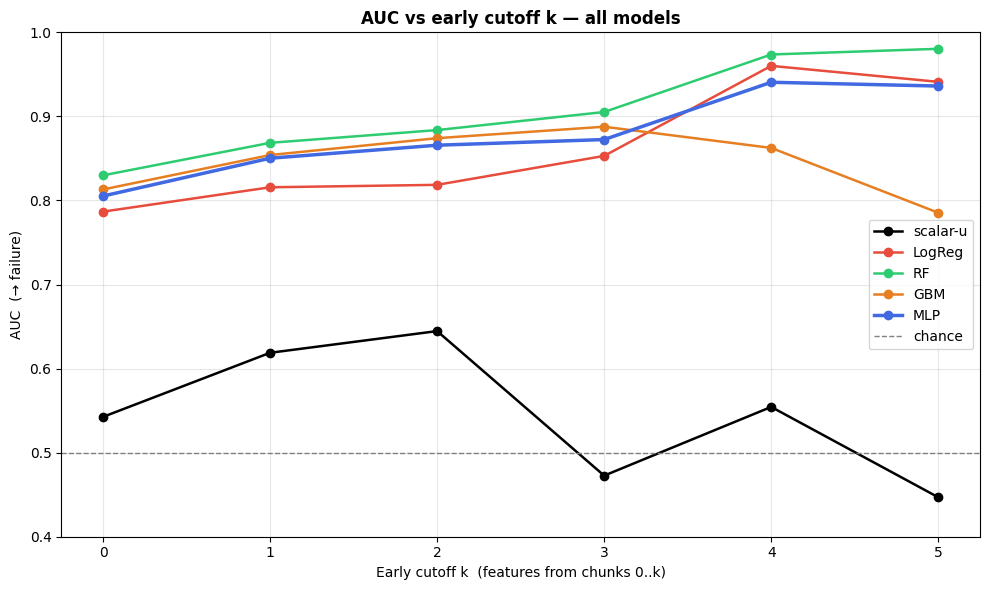

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for name in MODEL_ORDER:
    vals = [all_results[k][name]['m']['auc'] if all_results[k].get(name) else np.nan for k in ks]
    ax.plot(ks, vals, marker='o', lw=2.5 if name == 'MLP' else 1.8,
            color=MODEL_COLORS[name], label=name)
ax.axhline(0.5, color='gray', ls='--', lw=1, label='chance')
ax.set_xlabel('Early cutoff k  (features from chunks 0..k)')
ax.set_ylabel('AUC  (→ failure)')
ax.set_title('AUC vs early cutoff k — all models', fontweight='bold')
ax.set_xticks(ks); ax.set_ylim(0.4, 1.0); ax.grid(alpha=0.3); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/clf_auc_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. MLP training curves

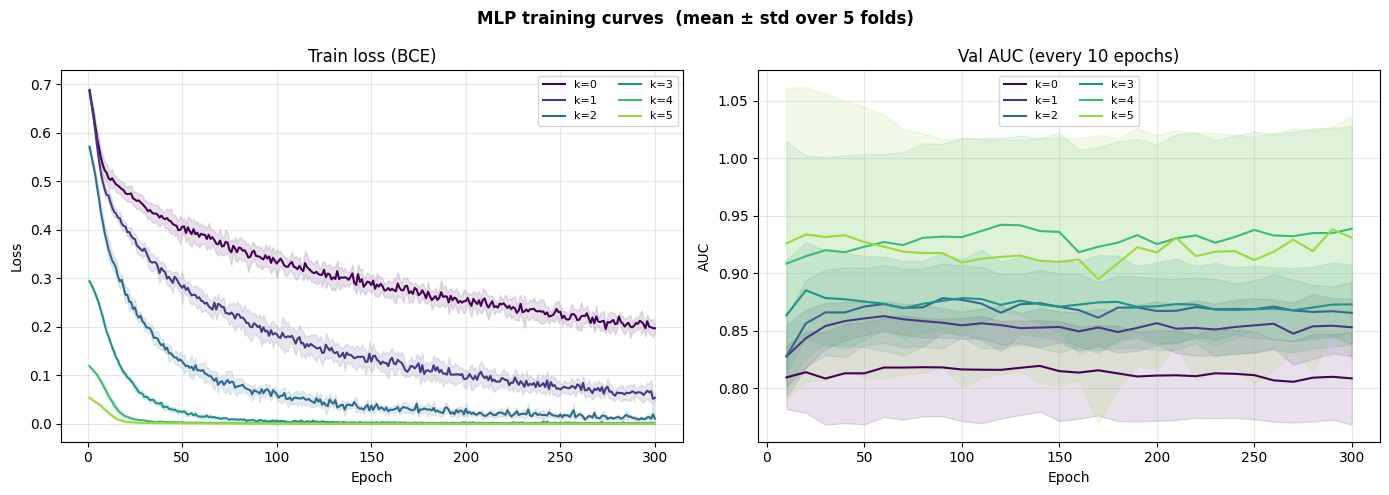

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLP training curves  (mean ± std over 5 folds)', fontweight='bold')
palette    = plt.cm.viridis(np.linspace(0, 0.85, MAX_K + 1))
epochs_tr  = list(range(1, N_EPOCHS + 1))
epochs_va  = list(range(10, N_EPOCHS + 1, 10))

for k, col in zip(ks, palette):
    r = all_results[k]['MLP']
    if r is None: continue
    tl = r['tr_loss']; va = r['val_auc']
    axes[0].plot(epochs_tr, tl.mean(0), color=col, lw=1.5, label=f'k={k}')
    axes[0].fill_between(epochs_tr, tl.mean(0)-tl.std(0), tl.mean(0)+tl.std(0), alpha=0.12, color=col)
    axes[1].plot(epochs_va, va.mean(0), color=col, lw=1.5, label=f'k={k}')
    axes[1].fill_between(epochs_va, va.mean(0)-va.std(0), va.mean(0)+va.std(0), alpha=0.12, color=col)

for ax, title, ylabel in zip(axes, ['Train loss (BCE)', 'Val AUC (every 10 epochs)'], ['Loss', 'AUC']):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/clf_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature importances
_(RF built-in, LogReg |coef|, MLP permutation)_

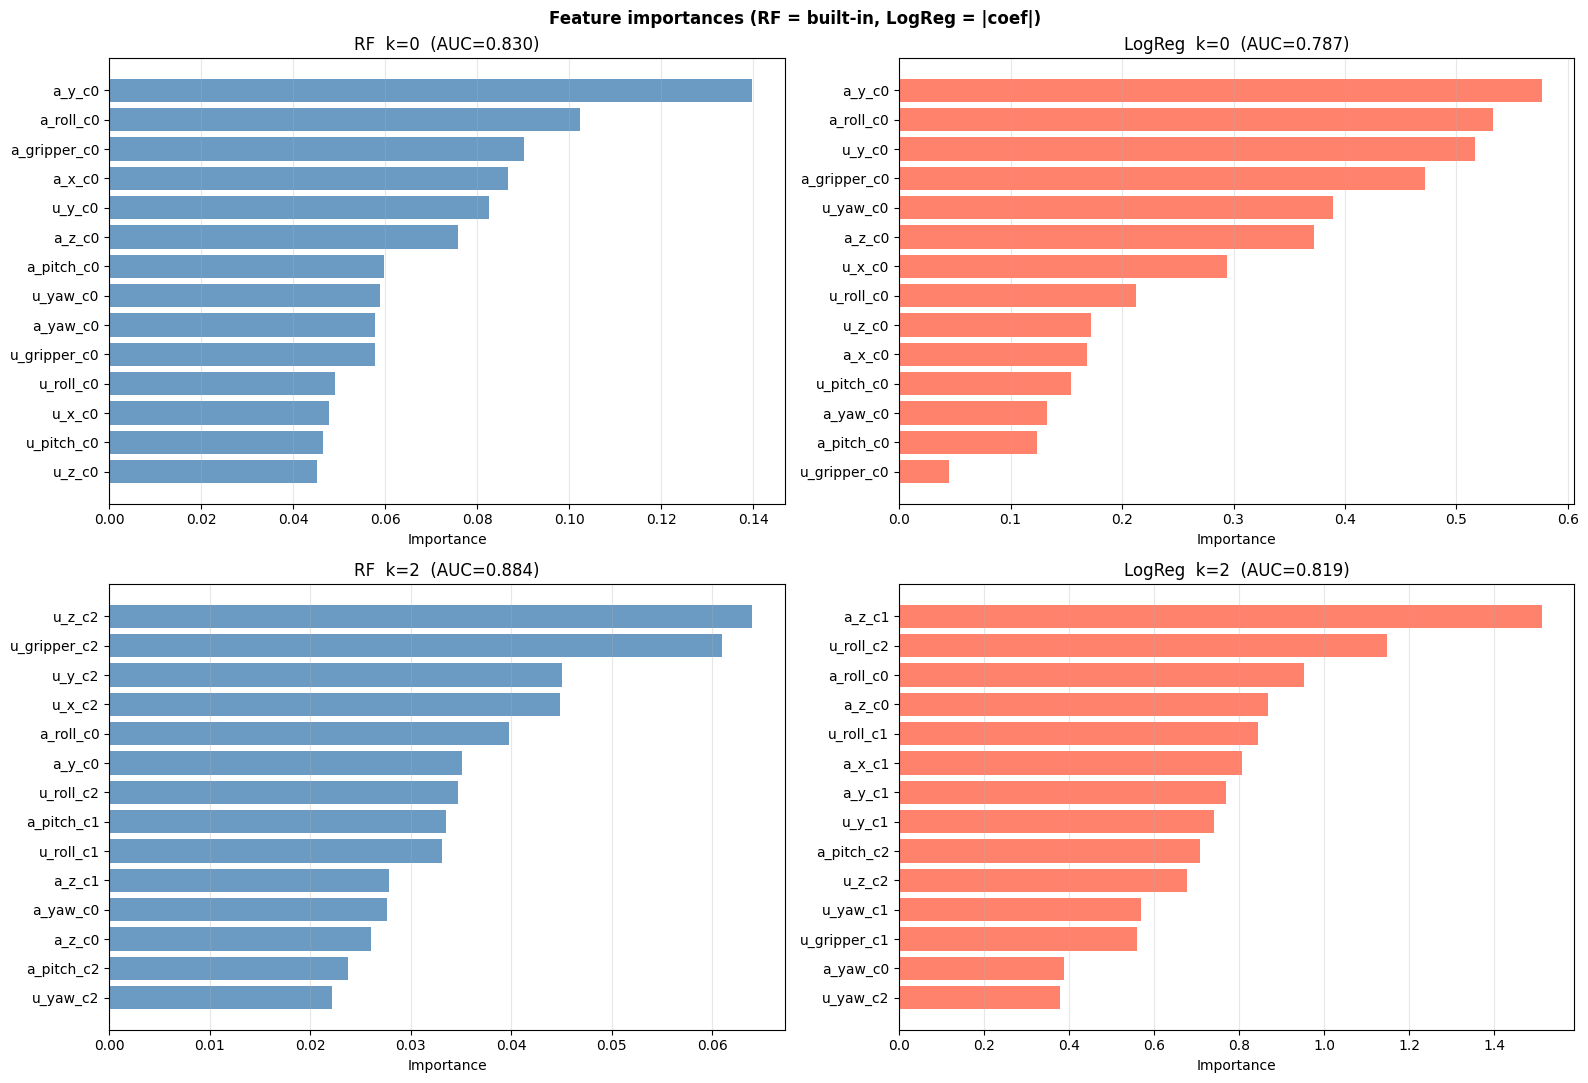

In [ ]:
K_IMP  = [k for k in [0, 2] if k <= MAX_K]
TOP_N  = 14
fig, axes = plt.subplots(len(K_IMP), 2, figsize=(16, 5.5 * len(K_IMP)))
if len(K_IMP) == 1: axes = axes[np.newaxis, :]
fig.suptitle('Feature importances (RF = built-in, LogReg = |coef|)', fontweight='bold')

for row, k in enumerate(K_IMP):
    fnames = feat_names(k)
    for col, mname in enumerate(['RF', 'LogReg']):
        ax  = axes[row, col]
        r   = all_results[k].get(mname)
        imp = r['imp'] if (r and r['imp'] is not None) else None
        if imp is None: ax.set_visible(False); continue
        top = np.argsort(imp)[::-1][:TOP_N]
        ax.barh([fnames[i] for i in top[::-1]], imp[top[::-1]],
                color='steelblue' if mname == 'RF' else 'tomato', alpha=0.8)
        ax.set_title(f'{mname}  k={k}  (AUC={r["m"]["auc"]:.3f})')
        ax.set_xlabel('Importance'); ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/clf_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

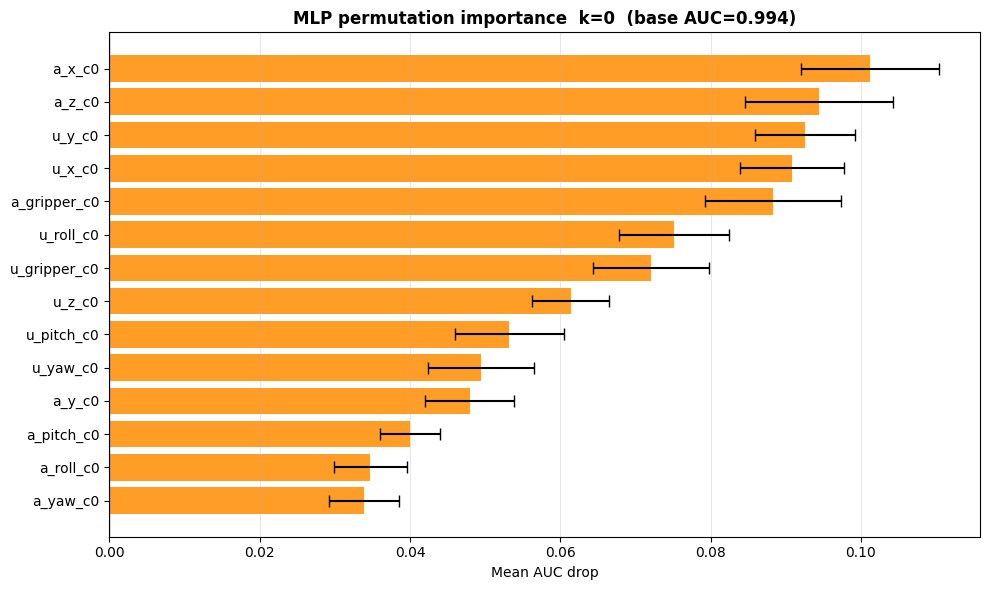

In [ ]:
# ── MLP permutation importance at k=0 ────────────────────────────────────────
k_pi = 0
X_pi, y_pi, _ = build_Xy(k_pi)
sc_pi = StandardScaler().fit(X_pi)
Xb_pi, yb_pi = oversample(sc_pi.transform(X_pi), y_pi)
pw_pi = torch.tensor([(1-y_pi).sum() / max(y_pi.sum(), 1)], device=DEVICE)
Xt_pi = torch.tensor(Xb_pi, dtype=torch.float32).to(DEVICE)
yt_pi = torch.tensor(yb_pi, dtype=torch.float32).to(DEVICE)
full_mlp = FailureMLP(X_pi.shape[1]).to(DEVICE)
opt_pi   = torch.optim.Adam(full_mlp.parameters(), lr=LR, weight_decay=WD)
crit_pi  = nn.BCEWithLogitsLoss(pos_weight=pw_pi)
dl_pi    = DataLoader(TensorDataset(Xt_pi, yt_pi), batch_size=64, shuffle=True)
full_mlp.train()
for _ in range(N_EPOCHS):
    for xb, yb in dl_pi:
        opt_pi.zero_grad(); crit_pi(full_mlp(xb), yb).backward(); opt_pi.step()
full_mlp.eval()

def mlp_score(X_in):
    with torch.no_grad():
        return torch.sigmoid(
            full_mlp(torch.tensor(sc_pi.transform(X_in), dtype=torch.float32).to(DEVICE))
        ).cpu().numpy()

N_REP = 20; rng = np.random.default_rng(0)
base_auc = roc_auc_score(y_pi, mlp_score(X_pi))
perm_delta = np.zeros((N_REP, X_pi.shape[1]))
for rep in range(N_REP):
    for f in range(X_pi.shape[1]):
        Xp = X_pi.copy(); rng.shuffle(Xp[:, f])
        perm_delta[rep, f] = base_auc - roc_auc_score(y_pi, mlp_score(Xp))

p_mean, p_std = perm_delta.mean(0), perm_delta.std(0)
fnames_pi = feat_names(k_pi)
top_pi    = np.argsort(p_mean)[::-1][:14]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([fnames_pi[i] for i in top_pi[::-1]], p_mean[top_pi[::-1]],
        xerr=p_std[top_pi[::-1]], color='darkorange', alpha=0.85, capsize=4)
ax.axvline(0, color='gray', lw=1)
ax.set_title(f'MLP permutation importance  k={k_pi}  (base AUC={base_auc:.3f})', fontweight='bold')
ax.set_xlabel('Mean AUC drop'); ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/clf_mlp_perm_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Confusion matrices + PR curves at k=0

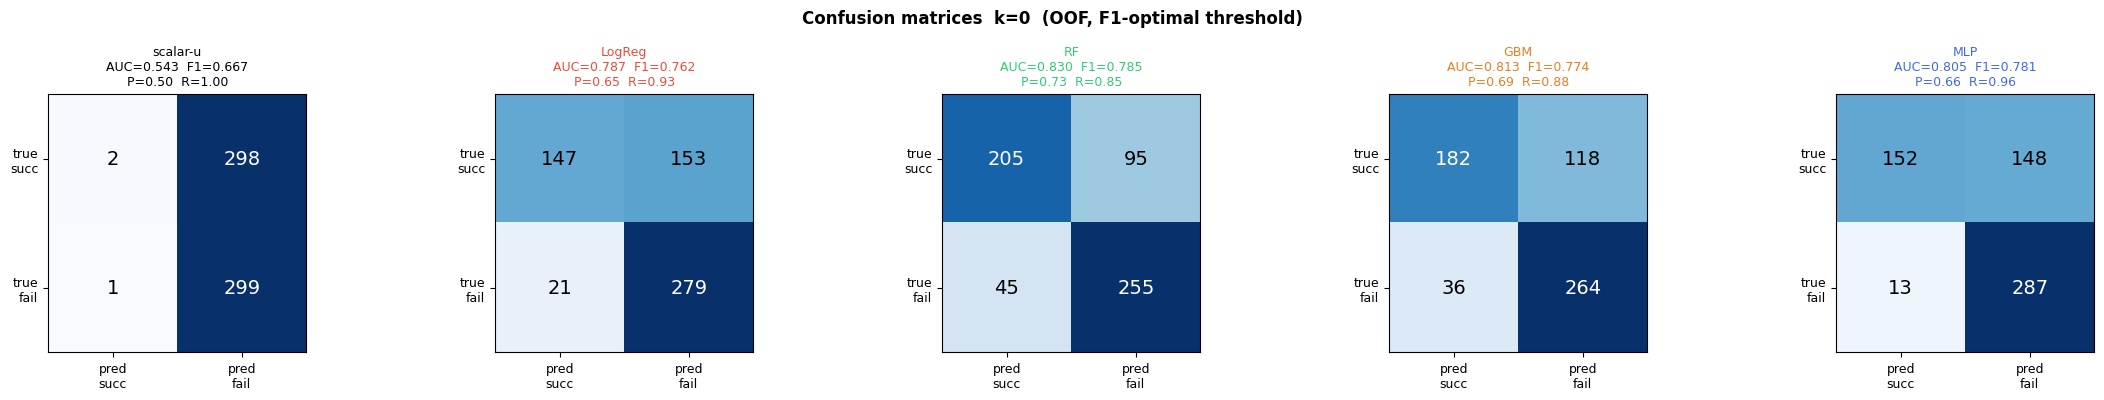

In [ ]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4.5 * len(MODEL_ORDER), 4))
fig.suptitle('Confusion matrices  k=0  (OOF, F1-optimal threshold)', fontweight='bold')
for ax, name in zip(axes, MODEL_ORDER):
    r = all_results[0].get(name)
    if r is None: ax.set_visible(False); continue
    cm = r['m']['cm']
    ax.imshow(cm, cmap='Blues', vmin=0)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                    color='white' if cm[i, j] > cm.max() * 0.6 else 'black')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['pred\nsucc', 'pred\nfail'], fontsize=9)
    ax.set_yticklabels(['true\nsucc', 'true\nfail'], fontsize=9)
    m = r['m']
    ax.set_title(f'{name}\nAUC={m["auc"]:.3f}  F1={m["f1"]:.3f}\n'
                 f'P={m["prec"]:.2f}  R={m["rec"]:.2f}', fontsize=9,
                 color=MODEL_COLORS.get(name, 'black'))
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/clf_confusion_k0.png', dpi=150, bbox_inches='tight')
plt.show()

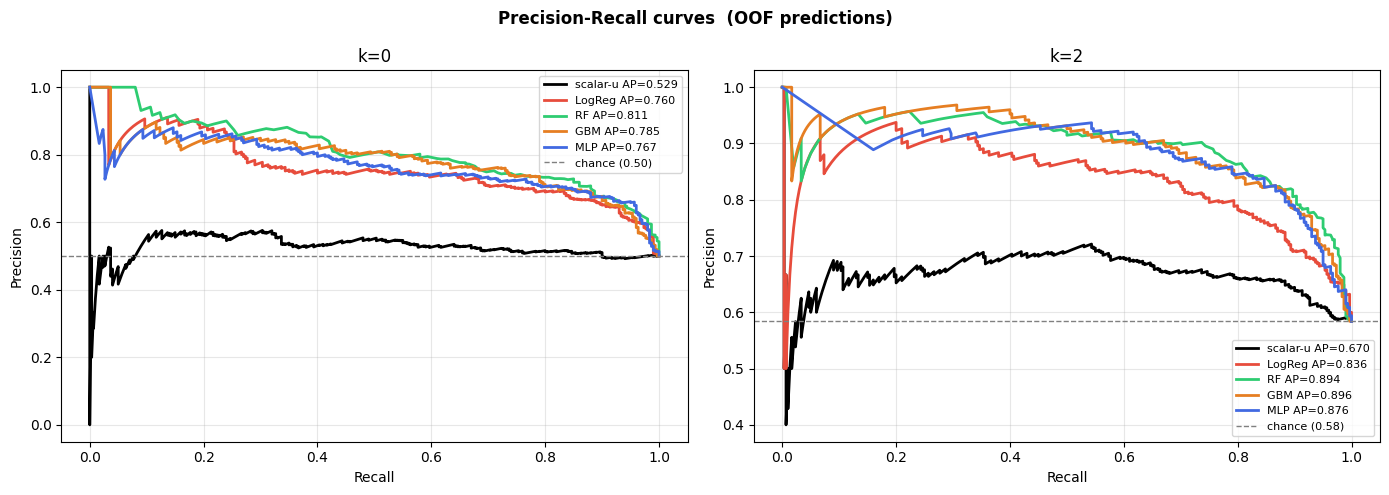

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Precision-Recall curves  (OOF predictions)', fontweight='bold')
for ax, k_pr in zip(axes, [0, MAX_K // 2]):
    _, y_pr, _ = build_Xy(k_pr)
    for name in MODEL_ORDER:
        r = all_results[k_pr].get(name)
        if r is None: continue
        p, rec, _ = precision_recall_curve(y_pr, r['oof'])
        ax.plot(rec, p, lw=2, color=MODEL_COLORS[name], label=f'{name} AP={r["m"]["ap"]:.3f}')
    ax.axhline(y_pr.mean(), color='gray', ls='--', lw=1, label=f'chance ({y_pr.mean():.2f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'k={k_pr}'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/clf_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. (Optional) Augment with observation + language encodings

Set `USE_ENCODINGS = True` once Section 0 has been run (policy loaded).

**How encodings are extracted (no extra rollouts needed):**
- LIBERO init states are deterministic: `(suite, task_idx, episode_idx)` → fixed `init_state`
- Image encoding: `policy.model.paligemma_with_expert.embed_image(img)` → SigLIP patch features,
  mean-pooled → 2048-dim vector per camera, concatenated across cameras
- Language encoding: tokenize task string → `embed_language_tokens` → mean-pool → 2048-dim vector
- ~600 env resets total; results cached to Drive as `mlp_encodings.pkl`

In [ ]:
import os, pickle, importlib, sys, glob
from sklearn.decomposition import PCA
from libero.libero import benchmark as _bm, get_libero_path
from libero.libero.envs import OffScreenRenderEnv

importlib.reload(_bm)
bm_dict = _bm.get_benchmark_dict()
print(f'Benchmark dict keys: {sorted(bm_dict.keys())}')

LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
ENC_PKL     = f'{SAVE_DIR}/mlp_encodings.pkl'

con2 = sqlite3.connect(DB)
roll_enc = pd.read_sql(f"SELECT rollout_id, suite, task_idx, episode_idx, success FROM rollouts WHERE pnp_enabled=1 AND pnp_mode='{PHASE}'", con2)
con2.close()

Benchmark dict keys: ['libero_10', 'libero_100', 'libero_10_env', 'libero_10_lan', 'libero_10_object', 'libero_10_object_ood', 'libero_10_relation_ood', 'libero_10_semantic_ood', 'libero_10_swap', 'libero_10_task', 'libero_10_temp', 'libero_10_with_alphabet_soup', 'libero_10_with_blue_stick', 'libero_10_with_diffpos_stick', 'libero_10_with_milk', 'libero_10_with_mug', 'libero_10_with_red_box', 'libero_10_with_red_stick', 'libero_90', 'libero_goal', 'libero_goal_env', 'libero_goal_lan', 'libero_goal_object', 'libero_goal_object_ood', 'libero_goal_relation_ood', 'libero_goal_semantic_ood', 'libero_goal_swap', 'libero_goal_task', 'libero_goal_temp', 'libero_goal_with_alphabet_soup', 'libero_goal_with_blue_stick', 'libero_goal_with_diffpos_stick', 'libero_goal_with_green_mug', 'libero_goal_with_milk', 'libero_goal_with_mug', 'libero_goal_with_red_box', 'libero_goal_with_red_stick', 'libero_goal_with_rotated_stick', 'libero_goal_with_yellow_book', 'libero_mine', 'libero_object', 'libero_obj

In [ ]:
def get_encodings(obs_dict, task_desc):
    raw   = obs_to_policy(obs_dict, task_desc, device)
    batch = preprocess(raw)
    images, _ = policy._preprocess_images(batch)
    img_encs  = []
    for img in images:
        with torch.no_grad():
            enc = policy.model.paligemma_with_expert.embed_image(img)
        img_encs.append(enc.mean(dim=1).squeeze(0).cpu().float().numpy())
    obs_enc = np.concatenate(img_encs)
    tok = tokenizer(task_desc, return_tensors='pt',
                    truncation=True, max_length=64).to(device)
    with torch.no_grad():
        lang_emb = policy.model.paligemma_with_expert.embed_language_tokens(tok['input_ids'])
    lang_enc = lang_emb.mean(dim=1).squeeze(0).cpu().float().numpy()
    return obs_enc, lang_enc

def bddl_language(bddl_path):
    with open(bddl_path) as f:
        for line in f:
            line = line.strip()
            if line.lower().startswith('(task_name') or line.lower().startswith('(:task'):
                return line.split(None, 1)[-1].rstrip(')').strip().strip('"')
    return os.path.splitext(os.path.basename(bddl_path))[0].replace('_', ' ')

def bddl_path_for(suite_name, task_idx):
    bddl_dir = os.path.join(LIBERO_SITE, 'bddl_files', suite_name)
    files    = sorted(glob.glob(os.path.join(bddl_dir, '*.bddl')))
    if task_idx < len(files):
        return files[task_idx]
    return None

def load_init_states_direct(suite_name, task_idx):
    bddl = bddl_path_for(suite_name, task_idx)
    if bddl is None:
        return None
    stem     = os.path.splitext(os.path.basename(bddl))[0]
    init_dir = os.path.join(LIBERO_SITE, 'init_files', suite_name)
    for ext in ('.pruned_init', '.init'):
        fp = os.path.join(init_dir, stem + ext)
        if os.path.exists(fp):
            return torch.load(fp, weights_only=False)
    return None

In [ ]:
if os.path.exists(ENC_PKL):
    with open(ENC_PKL, 'rb') as f:
        enc_cache = pickle.load(f)
    obs_encs  = enc_cache['obs']
    lang_encs = enc_cache['lang']
    print(f'Resuming from partial cache: {len(obs_encs)} obs already cached')
else:
    obs_encs, lang_encs = {}, {}

unique_tasks = roll_enc[['suite','task_idx','episode_idx']].drop_duplicates()
print(f'Encoding {len(unique_tasks)} unique (suite, task, ep) combos ...')

for suite_name, grp in unique_tasks.groupby('suite'):
    suite_eps  = set(zip(grp['task_idx'], grp['episode_idx']))
    cached_eps = {(k[1], k[2]) for k in obs_encs if k[0] == suite_name}
    if suite_eps <= cached_eps:
        print(f'  {suite_name} already fully cached — skip')
        continue

    if suite_name in bm_dict:
        task_suite = bm_dict[suite_name]()
        for task_idx, tg in grp.groupby('task_idx'):
            task        = task_suite.get_task(task_idx)
            init_states = task_suite.get_task_init_states(task_idx)
            bddl        = os.path.join(get_libero_path('bddl_files'),
                                        task.problem_folder, task.bddl_file)
            task_lang   = task.language
            env = OffScreenRenderEnv(
                bddl_file_name=bddl, camera_names=CAMERAS,
                camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
                has_offscreen_renderer=True, use_camera_obs=True,
                has_renderer=False, reward_shaping=False,
            )
            for ep_idx in tg['episode_idx'].values:
                key_obs = (suite_name, int(task_idx), int(ep_idx))
                if key_obs in obs_encs: continue
                env.reset()
                obs = env.set_init_state(init_states[ep_idx])
                for _ in range(NUM_STEPS_WAIT):
                    obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)
                oe, le = get_encodings(obs, task_lang)
                obs_encs[key_obs] = oe
                lang_encs[(suite_name, int(task_idx))] = le
            env.close()
    else:
        print(f'  {suite_name}: not in bm_dict — using direct file path')
        for task_idx, tg in grp.groupby('task_idx'):
            bddl = bddl_path_for(suite_name, int(task_idx))
            if bddl is None:
                print(f'    SKIP task {task_idx}: no BDDL found'); continue
            task_lang   = bddl_language(bddl)
            init_states = load_init_states_direct(suite_name, int(task_idx))
            if init_states is None:
                print(f'    SKIP task {task_idx}: no init states found'); continue
            env = OffScreenRenderEnv(
                bddl_file_name=bddl, camera_names=CAMERAS,
                camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
                has_offscreen_renderer=True, use_camera_obs=True,
                has_renderer=False, reward_shaping=False,
            )
            for ep_idx in tg['episode_idx'].values:
                key_obs = (suite_name, int(task_idx), int(ep_idx))
                if key_obs in obs_encs: continue
                env.reset()
                state = init_states if init_states.ndim == 1 else init_states[int(ep_idx)]
                obs = env.set_init_state(state)
                for _ in range(NUM_STEPS_WAIT):
                    obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)
                oe, le = get_encodings(obs, task_lang)
                obs_encs[key_obs] = oe
                lang_encs[(suite_name, int(task_idx))] = le
            env.close()

    # Checkpoint after each suite
    with open(ENC_PKL, 'wb') as f:
        pickle.dump({'obs': obs_encs, 'lang': lang_encs}, f)
    print(f'  {suite_name} done  ({len([k for k in obs_encs if k[0]==suite_name])} obs cached) — checkpoint saved')

obs_dim  = next(iter(obs_encs.values())).shape[0]
lang_dim = next(iter(lang_encs.values())).shape[0]
print(f'obs_enc dim={obs_dim}  lang_enc dim={lang_dim}  total cached={len(obs_encs)}')

Resuming from partial cache: 100 obs already cached
Encoding 600 unique (suite, task, ep) combos ...
  libero_goal_with_yellow_book already fully cached — skip
  libero_object_temp_x0.1: not in bm_dict — using direct file path
  libero_object_temp_x0.1 done  (100 obs cached) — checkpoint saved
  libero_object_temp_x0.2: not in bm_dict — using direct file path
  libero_object_temp_x0.2 done  (100 obs cached) — checkpoint saved
  libero_object_temp_y0.1: not in bm_dict — using direct file path
  libero_object_temp_y0.1 done  (100 obs cached) — checkpoint saved
  libero_object_temp_y0.2: not in bm_dict — using direct file path
  libero_object_temp_y0.2 done  (100 obs cached) — checkpoint saved
[info] Using default task order for benchmark 'libero_spatial_with_milk' (10 tasks).
  libero_spatial_with_milk done  (100 obs cached) — checkpoint saved
obs_enc dim=6144  lang_enc dim=2048  total cached=600


In [ ]:
ENC_PCA_DIM = 32
all_obs  = np.stack([obs_encs[k]  for k in sorted(obs_encs)])
all_lang = np.stack([lang_encs[k] for k in sorted(lang_encs)])
pca_obs  = PCA(n_components=min(ENC_PCA_DIM, all_obs.shape[0]-1),  random_state=42).fit(all_obs)
pca_lang = PCA(n_components=min(ENC_PCA_DIM, all_lang.shape[0]-1), random_state=42).fit(all_lang)
obs_encs_pca  = {k: pca_obs.transform(v[None])[0]  for k, v in obs_encs.items()}
lang_encs_pca = {k: pca_lang.transform(v[None])[0] for k, v in lang_encs.items()}
print(f'PCA: obs {obs_dim}→{pca_obs.n_components_}')
print(f'(var={pca_obs.explained_variance_ratio_.sum():.2%})')
print(f'lang {lang_dim}→{pca_lang.n_components_}')
print(f'(var={pca_lang.explained_variance_ratio_.sum():.2%})')
print(f'lang {lang_dim}→{pca_lang.n_components_}')
print(f'(var={pca_lang.explained_variance_ratio_.sum():.2%})')

ep_enc = ep_chunks.merge(roll_enc[['rollout_id','suite','task_idx','episode_idx']], on='rollout_id', how='inner')

def build_Xy_enc(k):
    X, y = [], []
    for _, r in ep_enc.iterrows():
        if len(r['chunks']) < k + 1: continue
        feats = []
        for j in range(k + 1):
            u_j, a_j = r['chunks'][j]; feats.extend(u_j); feats.extend(a_j)
        oe = obs_encs_pca.get((r['suite'], int(r['task_idx']), int(r['episode_idx'])))
        le = lang_encs_pca.get((r['suite'], int(r['task_idx'])))
        if oe is None or le is None: continue
        feats.extend(oe); feats.extend(le)
        X.append(feats); y.append(1 - r['success'])
    return np.array(X, np.float32), np.array(y, np.float32)

PCA: obs 6144→32
(var=91.71%)
lang 2048→32
(var=100.00%)
lang 2048→32
(var=100.00%)


In [ ]:
enc_results = {}
for k in ks:
    Xe, ye = build_Xy_enc(k)
    re = train_mlp_cv(Xe, ye)
    enc_results[k] = re
    if re is None:
        print(f'k={k}  n={len(Xe)}  MLP+enc skipped (too few samples per class)')
    else:
        print(f'k={k}  n={len(Xe)}  MLP+enc AUC={re["m"]["auc"]:.3f}  F1={re["m"]["f1"]:.3f}')

k=0  n=600  MLP+enc AUC=0.844  F1=0.795
k=1  n=600  MLP+enc AUC=0.859  F1=0.804
k=2  n=514  MLP+enc AUC=0.839  F1=0.837
k=3  n=381  MLP+enc AUC=0.863  F1=0.935
k=4  n=328  MLP+enc AUC=0.961  F1=0.982
k=5  n=312  MLP+enc AUC=0.986  F1=0.990


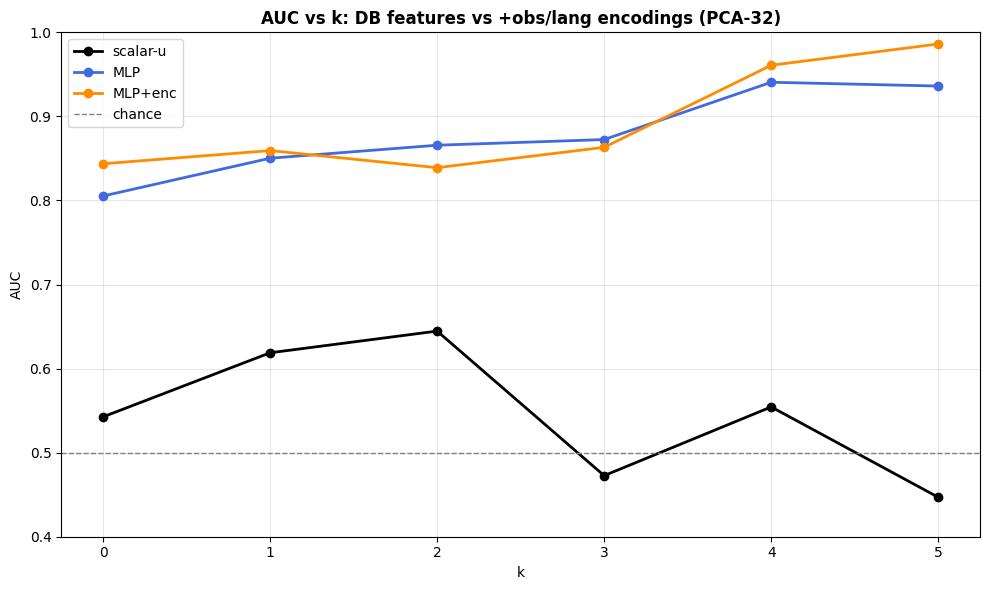

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for name, col in [('scalar-u', 'black'), ('MLP', 'royalblue'), ('MLP+enc', 'darkorange')]:
    if name == 'MLP+enc':
        vals = [enc_results[k]['m']['auc'] if enc_results.get(k) else np.nan for k in ks]
    else:
        vals = [all_results[k][name]['m']['auc'] if all_results[k].get(name) else np.nan for k in ks]
    ax.plot(ks, vals, marker='o', lw=2, color=col, label=name)
ax.axhline(0.5, color='gray', ls='--', lw=1, label='chance')
ax.set_xlabel('k'); ax.set_ylabel('AUC')
ax.set_title('AUC vs k: DB features vs +obs/lang encodings (PCA-32)', fontweight='bold')
ax.set_xticks(ks); ax.set_ylim(0.4, 1.0); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/clf_enc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
chunk_counts = ep_chunks.chunks.map(len)
success_chunks = ep_chunks.loc[ep_chunks.success == 1, 'chunks'].map(len)
failure_chunks = ep_chunks.loc[ep_chunks.success == 0, 'chunks'].map(len)

print(f'Successes — min:{success_chunks.min()} max:{success_chunks.max()} mean:{success_chunks.mean():.1f}')
print(f'Failures  — min:{failure_chunks.min()} max:{failure_chunks.max()} mean:{failure_chunks.mean():.1f}')
print(f'\nSurviving successes at each k:')
for k in range(MAX_K + 1):
    n_s = (success_chunks >= k+1).sum()
    n_f = (failure_chunks >= k+1).sum()
    print(f'  k={k}: {n_s} successes, {n_f} failures')

Successes — min:2 max:6 mean:3.1
Failures  — min:6 max:6 mean:6.0

Surviving successes at each k:
  k=0: 300 successes, 300 failures
  k=1: 300 successes, 300 failures
  k=2: 214 successes, 300 failures
  k=3: 81 successes, 300 failures
  k=4: 28 successes, 300 failures
  k=5: 12 successes, 300 failures
